In [202]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
trades = pd.read_csv(r"C:\Users\SRIKANT SENAPATI\Downloads\historical_data.csv")
sentiment = pd.read_csv(r"C:\Users\SRIKANT SENAPATI\Downloads\fear_greed_index.csv")

Number of rows/columns

In [12]:
trades.shape

(211224, 16)

In [11]:
sentiment.shape

(2644, 4)

Checking missing values

In [ ]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [14]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

Column name correction

In [21]:
trades.columns = trades.columns.str.lower().str.replace(' ','_')

In [22]:
trades.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')

In [25]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Duplicates checks

In [24]:
trades.duplicated().sum()

np.int64(0)

In [63]:
trades.head(3)

,account,coin,execution_price,size_tokens,size_usd,side,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12


In [27]:
sentiment.head(3)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


Optimizing the datatypes of date column for merging two data

In [55]:
sentiment['date'] = pd.to_datetime(sentiment['date'],errors = 'coerce')
trades['date'] = pd.to_datetime(trades['timestamp_ist'],errors = 'coerce').dt.date

In [57]:
trades['date'] = pd.to_datetime(trades['date'],errors = 'coerce')

In [62]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   account           211224 non-null  object        
 1   coin              211224 non-null  object        
 2   execution_price   211224 non-null  float64       
 3   size_tokens       211224 non-null  float64       
 4   size_usd          211224 non-null  float64       
 5   side              211224 non-null  object        
 6   start_position    211224 non-null  float64       
 7   direction         211224 non-null  object        
 8   closed_pnl        211224 non-null  float64       
 9   transaction_hash  211224 non-null  object        
 10  order_id          211224 non-null  int64         
 11  crossed           211224 non-null  bool          
 12  fee               211224 non-null  float64       
 13  trade_id          211224 non-null  float64       
 14  time

In [61]:
trades = trades.drop(columns=['timestamp_ist'])

Merging two data

In [67]:
df = pd.merge(trades, sentiment,on='date', how = 'inner')

In [68]:
df.head(3)

,account,coin,execution_price,size_tokens,size_usd,side,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp_x,date,timestamp_y,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed


Daily profit and loss

In [74]:
daily_pnl = df.groupby(['date','account'])['closed_pnl'].sum().reset_index()
daily_pnl

,date,account,closed_pnl
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-129.531460
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
4,2024-01-03,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,8244.241409
...,...,...,...
525,2025-05-02,0x8381e6d82f1affd39a336e143e081ef7620a3b7f,1843.301845
526,2025-05-02,0x8477e447846c758f5a675856001ea72298fd9cb5,554.257954
527,2025-05-02,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,-6194.283149
528,2025-05-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14644.100674


Win rate

In [125]:
df['win'] = df['closed_pnl'] > 0
win_rate = df.groupby('account')['win'].mean().reset_index()
win_rate

,account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.403057
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.400168
2,0x271b280974205ca63b716753467d5a371de622ab,0.750000
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.478261
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.518519
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.196078
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,0.272727
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,0.636364
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,0.181818
9,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000


In [115]:
df[['size_tokens','execution_price']].head()

,size_tokens,execution_price
0,986.87,7.9769
1,16.00,7.9800
2,144.09,7.9855
3,142.98,7.9874
4,8.73,7.9894


In [126]:
df['size_usd'].value_counts().head(10).reset_index()

,size_usd,count
0,1003.01,62
1,500.06,59
2,1017.21,41
3,496.51,39
4,1000.57,37
5,11.60,35
6,499.95,32
7,501.51,30
8,599.50,30
9,182.88,29


In [99]:
def leverage_proxy(x):
    if x < df['size_usd'].quantile(0.33):
        return 'Low'
    elif x < df['size_usd'].quantile(0.66):
        return 'Medium'
    else:
        return 'High'

df['leverage_group'] = df['size_usd'].apply(leverage_proxy)

In [127]:
df['leverage_group'].value_counts(normalize=True) * 100

leverage_group
High      34.017399
Low       32.999665
Medium    32.982936
Name: proportion, dtype: float64

Profit vs Leverage

In [97]:
df.groupby('leverage_group')['closed_pnl'].mean()

leverage_group
High      270.551129
Low         6.170419
Medium     21.223923
Name: closed_pnl, dtype: float64

In [103]:
df.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'start_position', 'direction', 'closed_pnl', 'transaction_hash',
       'order_id', 'crossed', 'fee', 'trade_id', 'timestamp_x', 'date',
       'timestamp_y', 'value', 'classification', 'win', 'leverage_group'],
      dtype='object')

Comparing with Sentiment

In [108]:
pd.crosstab(df['classification'],df['leverage_group'],normalize = 'index')*100

leverage_group,High,Low,Medium
classification,,,
Extreme Fear,32.416165,34.436801,33.147034
Extreme Greed,29.870130,45.596869,24.533001
Fear,35.027760,28.134689,36.837551
Greed,36.034361,29.631598,34.334042
Neutral,30.478955,44.375907,25.145138


Number of trades per day


In [155]:
trades_per_day = df.groupby('date').size().reset_index()
trades_per_day

,date,0
0,2023-01-05,3
1,2023-05-12,9
2,2024-01-01,18
3,2024-01-02,6
4,2024-01-03,137
...,...,...
153,2025-04-02,2512
154,2025-04-03,2402
155,2025-04-04,1272
156,2025-05-01,239


Long / Short Ratio

In [133]:
df['side'].value_counts(normalize=True).reset_index()

,side,proportion
0,SELL,0.538172
1,BUY,0.461828


In [135]:
df.head(2)

,account,coin,execution_price,size_tokens,size_usd,side,start_position,direction,closed_pnl,transaction_hash,...,crossed,fee,trade_id,timestamp_x,date,timestamp_y,value,classification,win,leverage_group
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,...,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed,False,High
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,...,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed,False,Low


Part (B)

1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

In [137]:
df.groupby('classification')['closed_pnl'].mean().reset_index()

,classification,closed_pnl
0,Extreme Fear,1.891632
1,Extreme Greed,205.816345
2,Fear,128.287950
3,Greed,53.988003
4,Neutral,27.088803


We can observe that traders earn the most during Extreme Greed.

2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?

In [ ]:
# Trade frequency
df.groupby('classification').size().reset_index()

,classification,0
0,Extreme Fear,2326
1,Extreme Greed,5621
2,Fear,13869
3,Greed,11292
4,Neutral,2756


We can observe that traders are most active when market is fearful

In [ ]:
# Position Size
df.groupby('classification')['size_usd'].mean().reset_index()

,classification,size_usd
0,Extreme Fear,4118.761840
1,Extreme Greed,3242.085086
2,Fear,5744.782685
3,Greed,5051.878829
4,Neutral,4332.202906


Traders allocate the highest capital during fear

In [172]:
# Long vs Short Bias
pd.crosstab(df['classification'], df['side'], normalize='index') * 100

side,BUY,SELL
classification,,
Extreme Fear,50.214961,49.785039
Extreme Greed,29.549902,70.450098
Fear,52.685846,47.314154
Greed,47.883457,52.116543
Neutral,37.010160,62.989840


Extreme greed shows heavy selling pressure, suggesting traders exit positions at market peaks.

2. High leverage vs low leverage traders


In [174]:
df.groupby('leverage_group')['closed_pnl'].mean().reset_index()

,leverage_group,closed_pnl
0,High,270.551129
1,Low,6.170419
2,Medium,21.223923


In [ ]:
# Frequent vs infrequent traders

trade_count = df.groupby('account').size()
threshold = trade_count.median()
def classify_trader(account):
    if trade_count[account] > threshold:
        return 'Frequent'
    else:
        return 'Infrequent'

df['trader_type'] = df['account'].apply(classify_trader)

In [180]:
df.groupby('trader_type')['closed_pnl'].mean().reset_index()

,trader_type,closed_pnl
0,Frequent,99.091235
1,Infrequent,129.087187


In [188]:
# consistent winners vs inconsistent traders
df['gain'] = df['closed_pnl'] > 0
gain_rate = df.groupby('account')['gain'].mean()

def classify_consistency(account):
    if gain_rate[account] > 0.6:
        return 'Consistent'
    else:
        return 'Inconsistent'

In [194]:
df['consistency'] = df['account'].apply(classify_consistency)
df.groupby('consistency').size().reset_index()

,consistency,0
0,Consistent,2405
1,Inconsistent,33459


Consistent traders tend to trade more selectively and avoid extreme market conditions compared to inconsistent traders.

INSIGHT 1: Performance vs Sentiment

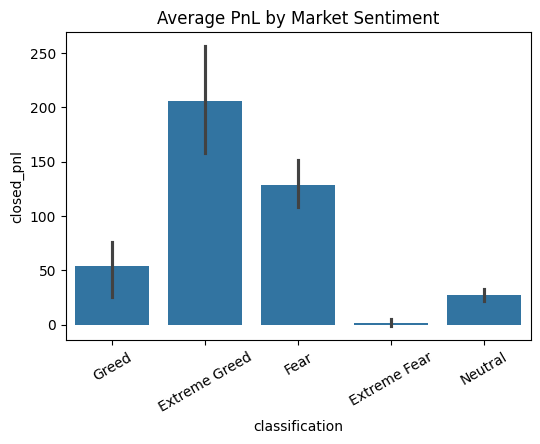

In [203]:
plt.figure(figsize=(6,4))
sns.barplot(x='classification', y='closed_pnl', data=df, estimator='mean')
plt.title('Average PnL by Market Sentiment')
plt.xticks(rotation=30)
plt.show()

Observations
* Highest PnL in Extreme Greed
* Fear also shows strong returns
* Extreme Fear is lowest

Trader performance peaks during Extreme Greed due to strong market momentum, while Fear conditions also yield relatively high returns. However, Extreme Fear leads to minimal profitability, indicating uncertainty-driven inefficiency.

INSIGHT 2: Risk Behavior (Position Size vs Sentiment)

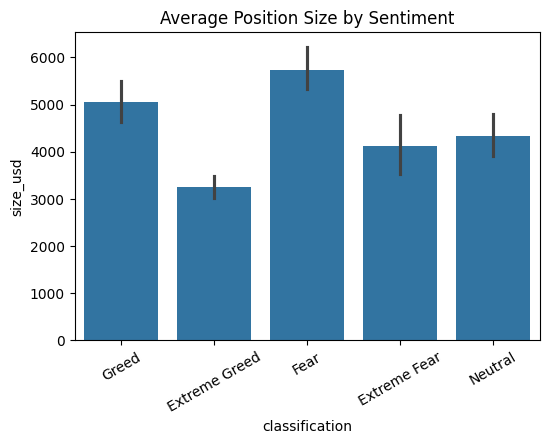

In [198]:
plt.figure(figsize=(6,4))
sns.barplot(x='classification', y='size_usd', data=df, estimator='mean')
plt.title('Average Position Size by Sentiment')
plt.xticks(rotation=30)
plt.show()

Observation
* Larger position sizes in Greed / Fear
* Smaller in Extreme Greed

Traders take larger positions during Greed phases, indicating increased risk appetite. In contrast, Extreme Greed conditions lead to smaller and more cautious trades

INSIGHT 3: Trader Consistency

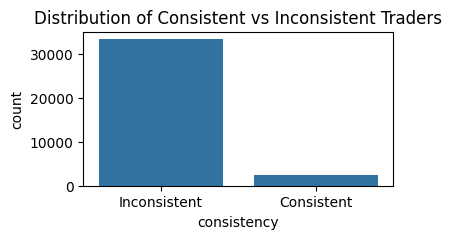

In [201]:
plt.figure(figsize=(4,2))
sns.countplot(x='consistency', data=df)
plt.title('Distribution of Consistent vs Inconsistent Traders')
plt.show()

Observation
* Huge majority = Inconsistent traders
* Very few consistent traders

Only a small fraction of traders are consistent performers, while the majority exhibit inconsistent outcomes, highlighting the difficulty of sustaining profitability in trading.

Seaborn visualizations reveal that market sentiment significantly influences both trader performance and risk-taking behavior.

Strategy 1: Risk Control During Fear Phases

Analysis shows that traders take the largest position sizes during Fear conditions, indicating aggressive dip-buying behavior. To mitigate risk, traders—especially high-risk participants—should limit position sizes and avoid overexposure during Fear phases.

Strategy 2: Trend-Based Participation in Extreme Greed

Extreme Greed phases exhibit strong profitability despite relatively smaller position sizes. Traders should increase participation during these periods while maintaining moderate position sizes, as strong trends allow profitable opportunities without excessive risk.